Questions on This Model

1. The first thing before anything else is creating a control run. Should that control run have a starting point of sigma_0 0.9? And what should I choose for temperature and salinity?
2. I think I have some confusion on teval. For t_eval, I have tmax*100, which saves only 100 timepoints per year-I think it's not enough? I should save it at least every day? 
3. For the trajectories that go into the rare event algorithm, should they be cut after the transient, or should they start from the beginning run, same question for computing mean, variance, std dev?
4. When calculating the probability of a rare event, (to put in the average return time), I'm using 3 standard deviations above the mean. I guess for AMOC, it should be 3 standard deviations below. Is that calculated from the control run?
5. With autocorrelation function, you stop the analysis as it decays to 0? And for the integral of the AC as well?
6. When you split the run into blocks of time, you use the resampling time/integral autocorrelation time to get the number of blocks you should split it into. This isn't an even number, so if I round down and there's a bit of data left, is it fine to cut it, or should I try to get an even number of blocks?
7. Just to confirm, k is computed based on average return time, and tau/resampling time are approximately equal to the integral autocorrelation time.
8. In order to stop and resample, I have to integrate the rare event algorithm with the code for the Gottwald model. To do that I guess I set tmax to the resampling time, and have the initial variables as inputs. I use values based on analysis of AMOC (time average and resampling time), but when I set the values in the clones i should perturb either salinity or temperature, which one?

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
control = pd.read_csv('../experiments/control_runs/control_run.csv')
fivethou = pd.read_csv('../experiments/control_runs/control_run5000_year.csv')
#control_offstate_salt = pd.read_csv('amocs/salt_35y_200traj_0k.csv')
#control_offstate_amoc = pd.read_csv('amocs/amoc_trans_off_40y_200traj_0k.csv')

In [3]:
#drop transient
control_dropped = fivethou.loc[fivethou['t']>=10]
control_dropped.head()

,t,x,y,z,T,S,S0,T0,AMOC
1000,10.00002,1.985022,1.506520,0.268272,0.572738,0.413498,0.5,0.5,0.159240
1001,10.01002,1.092700,0.033878,-0.527736,0.574582,0.413545,0.5,0.5,0.161037
1002,10.02002,1.688152,0.265514,-0.358462,0.572782,0.413468,0.5,0.5,0.159314
1003,10.03002,1.692159,-0.776113,-1.007188,0.572089,0.413519,0.5,0.5,0.158570
1004,10.04002,0.305149,1.184369,0.446429,0.570688,0.413855,0.5,0.5,0.156834


In [5]:
print(control_dropped['x'].mean())
print(control_dropped['y'].mean())
print(control_dropped['z'].mean())

1.0104572094642317
0.07297103627924936
0.2682117320493175


In [4]:
#select after transition for off states
off_state_salt = control_offstate_salt.loc[control_offstate_salt['Run name']>=20]
off_state_amoc = control_offstate_amoc.loc[control_offstate_amoc['Run name']>=20]

NameError: name 'control_offstate_salt' is not defined

In [5]:
control_sub = control_dropped.iloc[::1500, :]

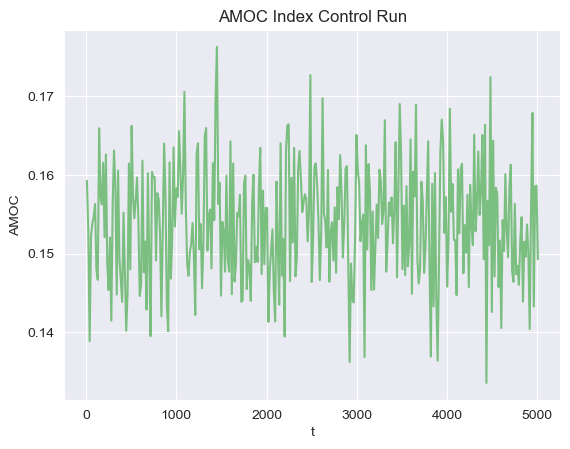

In [6]:
plt.figure()
colors = ['#7abe80','#ffbdbd', '#658e93', '#45954c']
sns.set_palette(sns.color_palette(colors))
sns.set_style("darkgrid")
sns.lineplot(data=control_sub,x='t',y='AMOC')
plt.title("AMOC Index Control Run")
plt.savefig('timeseries.png')

In [11]:
#find mean and standard deviation for Amoc index

#put amoc values in arrays for handling
#amoc_list = control_dropped['AMOC'].tolist()
amoc_list = control_dropped['AMOC'].tolist()
#amoc_list = off_state_amoc['AMOC'].tolist()
#add the same for T and S
#temp_list = control_dropped['T'].tolist()
#salt_list = control_dropped['S'].tolist()
temp_list = control_dropped['T'].tolist()
salt_list = control_dropped['S'].tolist()
#temp_list = off_state_amoc['T'].tolist()
#salt_list = off_state_amoc['S'].tolist()
#find mean and standard deviation
control_mean = np.mean(amoc_list)
control_std_dev = np.std(amoc_list)
control_variance = np.var(amoc_list)
salt_mean = np.mean(salt_list)
salt_std = np.std(salt_list)
salt_variance = np.var(salt_list)
temp_mean = np.mean(temp_list)
temp_std = np.std(temp_list)
temp_variance = np.var(temp_list)
print('mean: ',control_mean,'standard deviation: ',control_std_dev,'variance: ',control_variance)

mean:  0.15421270939787238 standard deviation:  0.007053883615238366 variance:  4.9757274057328275e-05


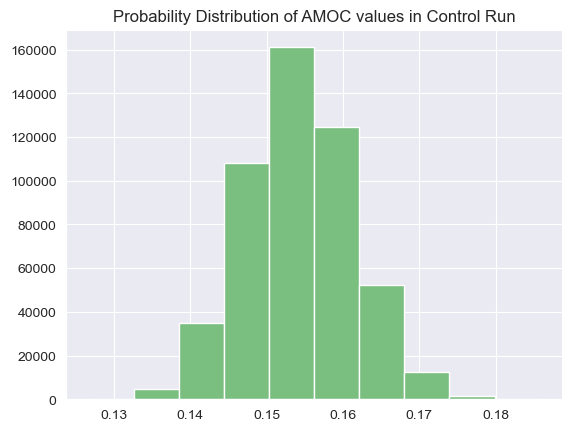

In [12]:
plt.hist(amoc_list)
plt.title('Probability Distribution of AMOC values in Control Run')
plt.savefig('control_hist.png')

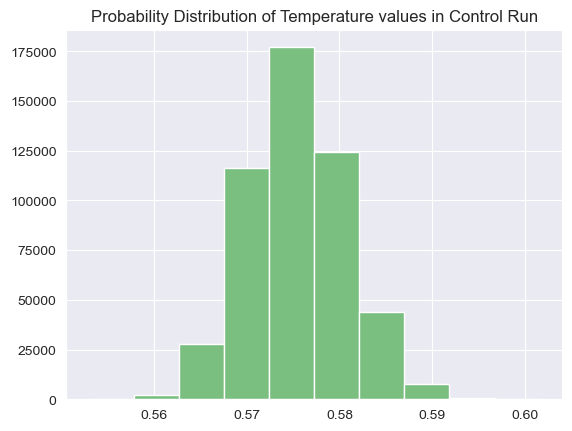

In [13]:
plt.hist(temp_list)
plt.title('Probability Distribution of Temperature values in Control Run')
plt.savefig('temp_hist.png')

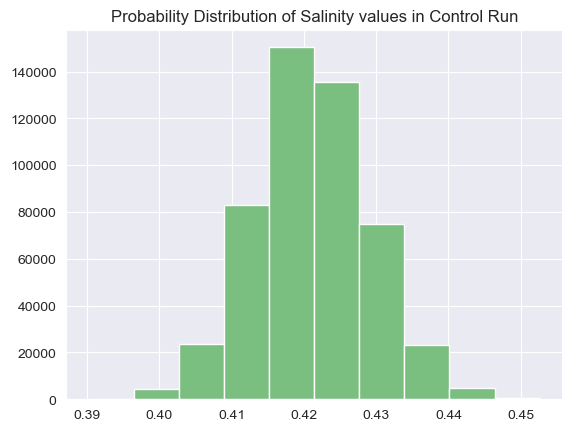

In [14]:
plt.hist(salt_list)
plt.title('Probability Distribution of Salinity values in Control Run')
plt.savefig('salt_hist.png')

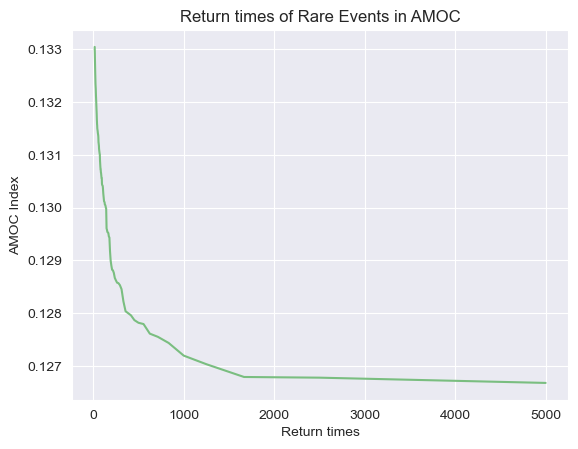

In [15]:
#return time function - calculate return time - probability that x is less than a for each a (need to calculate a)
delta_t=0.01
return_times = []
#decide on a - values below 3 std dev below mean
threshold_a = control_mean - 3*control_std_dev
a_list = []
#construct list of all a 
for val in sorted(amoc_list):
    if val<=threshold_a:
        a_list.append(val)
        
#find probability of x is less than a for all a, find return time
for val in range(1,len(a_list)+1):
    #number of values less is number that val is in the list
    prob_less = val/len(amoc_list)
    return_time = delta_t/prob_less
    return_times.append(return_time)

return_data = pd.DataFrame(data={'Return times':return_times,'AMOC Index':a_list})


sns.lineplot(data=return_data,x='Return times',y='AMOC Index').set_title('Return times of Rare Events in AMOC')
plt.savefig('returntimes_control.png')

In [16]:
'''
Auto-correlation Function:
Split time series into windows (100,000 timepoints/10 so 10 time windows of 10000 timesteps each)
compute AC function as average over all slices:
    - M=10, N=100,000
    - for i in range(M):
        - for t in range (N/M):
            - C[i,t] = y[i,0] * y[i,t] - mu^2
            - ACF = np.mean(C,axis=0)

    then divide by variance
    Take average over all slices
    
deprecated code (was comparing only to 0 for each slice, should compare to all lags)
#change list to temp and salt 

slices = np.array_split(salt_list, 100)
products = []
slice_length = len(salt_list) // 100
expectations = np.zeros((100,slice_length))
for slice_num, slice in enumerate(slices):
    for i in range(len(slice)):
        expectations[slice_num,i] = (slice[0]-salt_mean)*(slice[i]-salt_mean)
        print(expectations)
    #print(slice[0],slice[i],control_mean**2)
#find mean of AC at each expected value of amoc
ACF_mean = np.mean(expectations, axis=0)
ACF = []

#divide by variance
for mean in ACF_mean:
    R_t = mean/salt_variance
    ACF.append(R_t)
'''

'\nAuto-correlation Function:\nSplit time series into windows (100,000 timepoints/10 so 10 time windows of 10000 timesteps each)\ncompute AC function as average over all slices:\n    - M=10, N=100,000\n    - for i in range(M):\n        - for t in range (N/M):\n            - C[i,t] = y[i,0] * y[i,t] - mu^2\n            - ACF = np.mean(C,axis=0)\n\n    then divide by variance\n    Take average over all slices\n    \ndeprecated code (was comparing only to 0 for each slice, should compare to all lags)\n#change list to temp and salt \n\nslices = np.array_split(salt_list, 100)\nproducts = []\nslice_length = len(salt_list) // 100\nexpectations = np.zeros((100,slice_length))\nfor slice_num, slice in enumerate(slices):\n    for i in range(len(slice)):\n        expectations[slice_num,i] = (slice[0]-salt_mean)*(slice[i]-salt_mean)\n        print(expectations)\n    #print(slice[0],slice[i],control_mean**2)\n#find mean of AC at each expected value of amoc\nACF_mean = np.mean(expectations, axis=0)\n

In [27]:
amoc_list = np.array(temp_list)
print(len(target_list))
num_slices = 1000
slice_length = len(target_list) // num_slices

#Split series into slices
slices = np.array_split(target_list, num_slices)

#Initialize array to store ACF for each slice
expectations = np.zeros((num_slices, slice_length))

for slice_num, s in enumerate(slices):
    s = np.array(s)
    mean_s = np.mean(s)
    var_s = np.var(s)

    #Compute autocovariance for each lag
    for lag in range(slice_length):
        #Take all overlapping pairs at this lag, s[:len(s)-lag] -> all except last values, (s[lag:]) -> all except first vals
        products = (s[:len(s)-lag] - mean_s) * (s[lag:] - mean_s)
        expectations[slice_num, lag] = np.mean(products) / var_s 

#Average ACF across slices
ACF = np.mean(expectations, axis=0)

500000


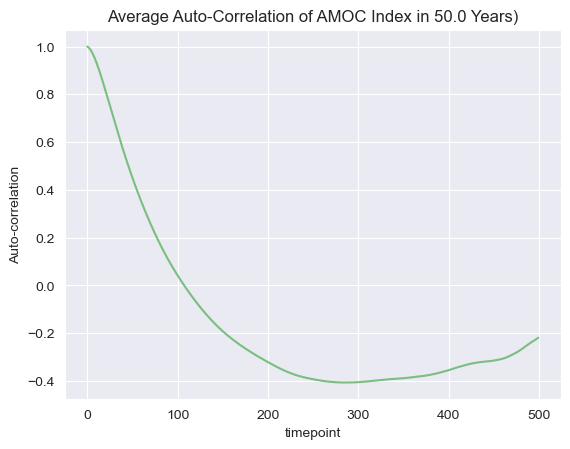

In [31]:
#plot autocorrelation function
title_var = slice_length/10
plt.figure()
plt.plot(ACF)
plt.title(f"Average Auto-Correlation of AMOC Index in {title_var} Years)")
plt.xlabel('timepoint')
plt.ylabel('Auto-correlation')
plt.savefig('acfunc_salt.png')

In [29]:
#integral auto-correlation time (system memory), tau
mults=[]
delta_t=0.01
for auto in range(len(ACF)):
    mults.append(ACF[auto]*delta_t)
tau = np.sum(mults)
print(tau)

-0.752794601105729


In [30]:
#compute k
#print(salt_variance)
#a = control_mean + 30*control_std_dev
a = salt_mean - 30*salt_std
#a = temp_mean - 30*temp_std
print(a)
#print(salt_std)
#print(a)
#k=a/(tau*control_variance)
k=a/(tau*salt_variance)
#k=a/(tau*salt_variance)
print(k)
#solve for a to find original anomaly
k=-500
a=k*(tau/control_variance)
print(a)
anomaly = (a-control_mean)/control_std_dev
print("anomalY:",anomaly)
#target value of a where trajectory drops to
k=(0.45)/tau/salt_variance
#target value of a where edge state
#k=(0.15)/tau/control_variance
#print(k)

0.18409701815834378
-3914.3771919408246
7564668.83855404
anomalY: 1072411893.499281
